In [1]:
import os, sys, glob, shutil, re, pickle
import subprocess

import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import math
from IPython.display import Image, display
%matplotlib inline
nmer = 5
mpl.rcParams.update({'font.size': 16})

In [2]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [3]:
# Define the directory path
directory = "traj_data/"

remove_and_clean = False

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

Directory 'traj_data/' did not exist, so it has been created.


In [5]:
dist_res_file = '../../../utils/nspe_7_2_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)
gmx_distance_indices = np.array(df_dist_res.values.tolist())

distance_indices = gmx_distance_indices - 1 

# Ensure the omega_data directory exists
omega_path = 'traj_data/'

state_num = 11
HREX_dir = '../traj'
run_num = 1 # How many run

HREX_list = [f"HREX_{i}" for i in range(1, run_num + 1)]
for state in range(state_num):
    dists_list = []
    for HREX in HREX_list:
        HREX_path = f"{HREX_dir}/{HREX}"  

        xtcfile = f"{HREX_path}/state_{state}/HREMD.part0001.xtc"
        grofile = f"../nspe_7_2.amb2gmx/nspe_7_2_GMX.gro"
        
        # Load the trajectory
        traj = md.load(xtcfile, top=grofile)
        
        # Compute distances 
        dists = md.compute_distances(traj, distance_indices) * 10.0 # convert nm to Å
        dists_list.append(dists)
        
    # Save omegas
    concatenated_dists = np.vstack(dists_list)
    data_object = Data(concatenated_dists)
    save_path = f"{omega_path}dis_state{state}.pkl"
    data_object.save(save_path)
    print(f"Saved omegas for state {state} to {save_path}")


Saved omegas for state 0 to traj_data/dis_state0.pkl
Saved omegas for state 1 to traj_data/dis_state1.pkl
Saved omegas for state 2 to traj_data/dis_state2.pkl
Saved omegas for state 3 to traj_data/dis_state3.pkl
Saved omegas for state 4 to traj_data/dis_state4.pkl
Saved omegas for state 5 to traj_data/dis_state5.pkl
Saved omegas for state 6 to traj_data/dis_state6.pkl
Saved omegas for state 7 to traj_data/dis_state7.pkl
Saved omegas for state 8 to traj_data/dis_state8.pkl
Saved omegas for state 9 to traj_data/dis_state9.pkl
Saved omegas for state 10 to traj_data/dis_state10.pkl


In [6]:
nstates = 11

dist_all = []
for i in range(nstates):
    dist_path = f"traj_data/dis_state{i}.pkl"
    dist = Data.load(dist_path)
    dist = dist.array_list
    print(f'state {i}:, {np.array(dist).shape}')
    dist_all.append(dist)

dist_all = np.array(dist_all)
print(dist_all.shape)

state 0:, (20001, 90)
state 1:, (20001, 90)
state 2:, (20001, 90)
state 3:, (20001, 90)
state 4:, (20001, 90)
state 5:, (20001, 90)
state 6:, (20001, 90)
state 7:, (20001, 90)
state 8:, (20001, 90)
state 9:, (20001, 90)
state 10:, (20001, 90)
(11, 20001, 90)


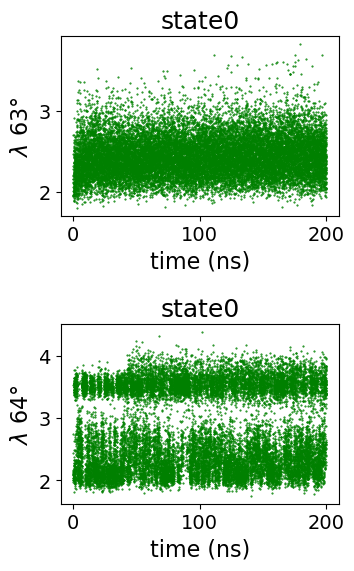

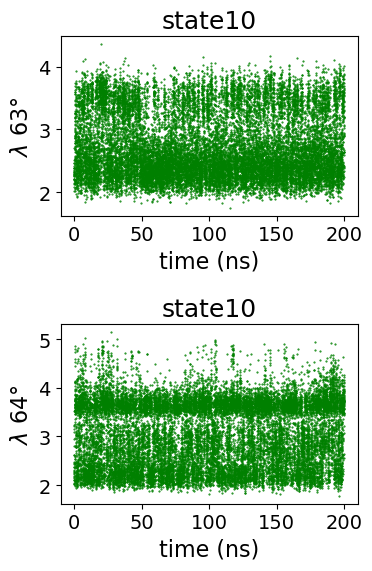

In [7]:
start = 0
nsnaps = dist_all.shape[1]
nreps = dist_all.shape[0]

residues_to_plot = [63, 64] # 1

#residues_to_plot = [0, 14, 70, 60] #5



num_residues = len(residues_to_plot)

ShowPlots = True

# Set default font sizes globally
plt.rc('font', size=16)         # controls default text sizes
plt.rc('axes', titlesize=18)    # fontsize of the axes title
plt.rc('axes', labelsize=16)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=14)   # fontsize of the tick labels
plt.rc('ytick', labelsize=14)   # fontsize of the tick labels
plt.rc('legend', fontsize=18)   # legend fontsize

# Plot omega angles vs time for selected residues for each replica
for i in [0, 10]:
    plt.figure(figsize=(4, 6))
    for panel, residue in enumerate(residues_to_plot, 1):
        plt.subplot(num_residues, 1, panel)
        t = np.arange(start, nsnaps) * 0.010  # Time axis in ns
        plt.plot(t, dist_all[i, start:nsnaps, residue], '.', ms=1, color='green')
        plt.xlabel('time (ns)')
        plt.ylabel(f'$\\lambda$ {residue}°')
    
        plt.title(f'state{i}')    
    plt.tight_layout()
    plt.show()

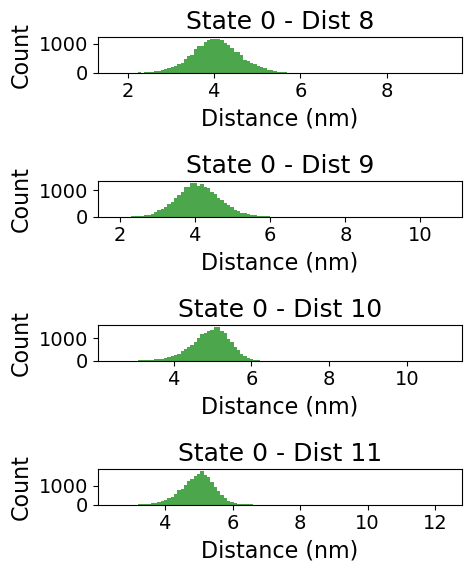

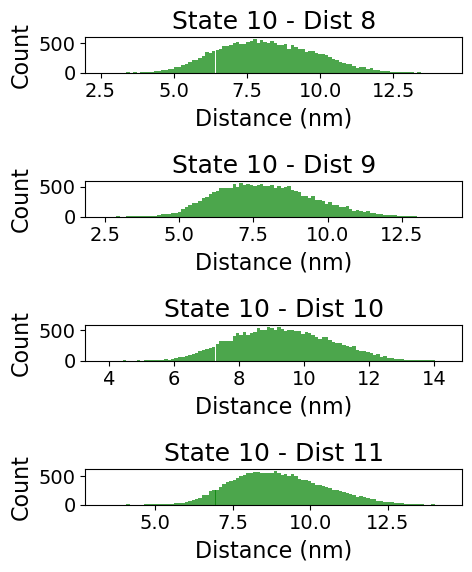

In [17]:
### Restrains Selected to show the effect, DON'T DELETE!!!!!!!!
#residues_to_plot = [41, 42] # 1 a11 - 2 a2
#residues_to_plot = [77, 78, 79, 80] # 2 a11 - 3 a11
#residues_to_plot = [31, 32, 33, 34] # 3 a11 - 4 a11
#residues_to_plot = [61, 62, 63, 64] # 4 a11 - 5 a11
#residues_to_plot = [48, 49] # 5 a11 - 6 a2
#residues_to_plot = [50, 51, 52, 53] # 6 a11 - 7 a11
residues_to_plot = [8, 9, 10, 11] # 3 a11 - 8 nh1

num_residues = len(residues_to_plot)
start = 0
nsnaps = dist_all.shape[1]
nreps = dist_all.shape[0]

for i in [0, 10]:  # loop over selected replicas
    plt.figure(figsize=(5, 1.5 * num_residues))  # Adjust figure height dynamically
    for panel, residue in enumerate(residues_to_plot, 1):
        plt.subplot(num_residues, 1, panel)
        distances = dist_all[i, start:nsnaps, residue]
        plt.hist(distances, bins=100, color='green', alpha=0.7)
        plt.xlabel(f'Distance (nm)')
        plt.ylabel('Count')
        #plt.xlim(0.1, 0.7)
        plt.title(f'State {i} - Dist {residue}')
    plt.tight_layout()
    plt.show()


In [8]:
# hand input the omega indices:
# Define omega dihedral indices, gromcas start from 1, while np start from 0
gmx_dihedral_indices = np.array([
    [10, 11, 26, 44],
    [44, 47, 49, 67], 
    [67, 70, 72, 90], 
    [90, 93, 95, 113], 
    [113, 116, 118, 136],
    [136, 139, 141, 159],
])

omega_dihedral_indices = gmx_dihedral_indices - 1
print(omega_dihedral_indices)

# Ensure the omega_data directory exists
omega_path = 'traj_data/'

state_num = 11
HREX_dir = '../traj'
run_num = 1 # How many run

HREX_list = [f"HREX_{i}" for i in range(1, run_num + 1)]
for state in range(state_num):
    omegas_list = []
    for HREX in HREX_list:
        HREX_path = f"{HREX_dir}/{HREX}"  

        xtcfile = f"{HREX_path}/state_{state}/HREMD.part0001.xtc"
        grofile = f"../nspe_7_2.amb2gmx/nspe_7_2_GMX.gro"
        
        # Load the trajectory
        traj = md.load(xtcfile, top=grofile)
        
        # Compute omega dihedrals
        omegas = md.compute_dihedrals(traj, omega_dihedral_indices) * (180.0 / math.pi)
        omegas_list.append(omegas)
    # Save omegas
    concatenated_omegas = np.vstack(omegas_list)
    data_object = Data(concatenated_omegas)
    save_path = f"{omega_path}omegas_state{state}.pkl"
    data_object.save(save_path)
    print(f"Saved omegas for state {state} to {save_path}")

[[  9  10  25  43]
 [ 43  46  48  66]
 [ 66  69  71  89]
 [ 89  92  94 112]
 [112 115 117 135]
 [135 138 140 158]]
Saved omegas for state 0 to traj_data/omegas_state0.pkl
Saved omegas for state 1 to traj_data/omegas_state1.pkl
Saved omegas for state 2 to traj_data/omegas_state2.pkl
Saved omegas for state 3 to traj_data/omegas_state3.pkl
Saved omegas for state 4 to traj_data/omegas_state4.pkl
Saved omegas for state 5 to traj_data/omegas_state5.pkl
Saved omegas for state 6 to traj_data/omegas_state6.pkl
Saved omegas for state 7 to traj_data/omegas_state7.pkl
Saved omegas for state 8 to traj_data/omegas_state8.pkl
Saved omegas for state 9 to traj_data/omegas_state9.pkl
Saved omegas for state 10 to traj_data/omegas_state10.pkl


In [9]:
nstates = 11

omega_all = []
for i in range(nstates):
    omega_path = f"traj_data/omegas_state{i}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    print(f'state {i}:, {np.array(omegas).shape}')
    omega_all.append(omegas)

omega_all = np.array(omega_all)
omega_all.shape

state 0:, (20001, 6)
state 1:, (20001, 6)
state 2:, (20001, 6)
state 3:, (20001, 6)
state 4:, (20001, 6)
state 5:, (20001, 6)
state 6:, (20001, 6)
state 7:, (20001, 6)
state 8:, (20001, 6)
state 9:, (20001, 6)
state 10:, (20001, 6)


(11, 20001, 6)

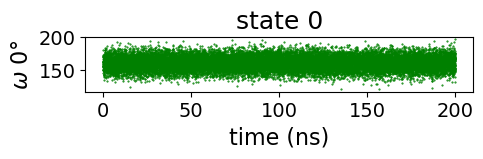

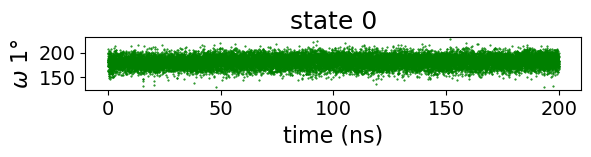

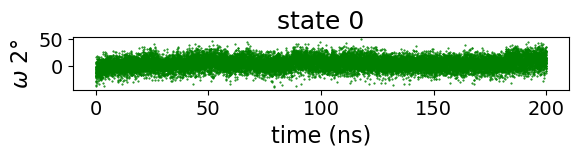

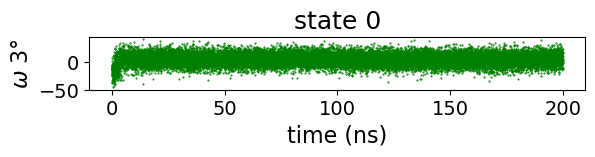

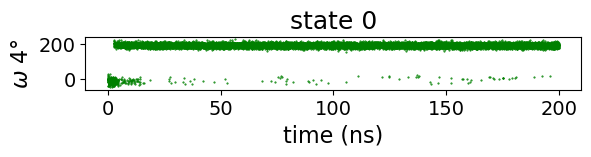

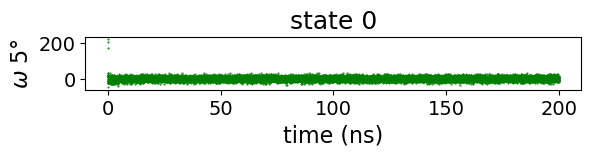

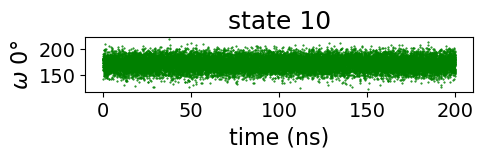

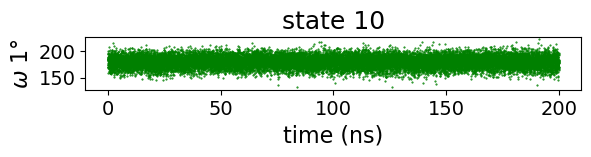

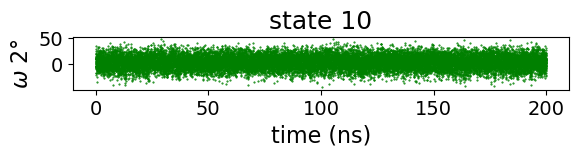

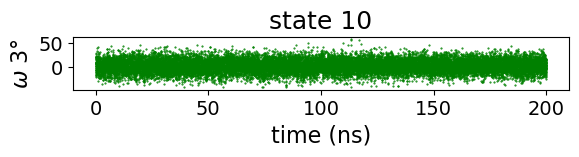

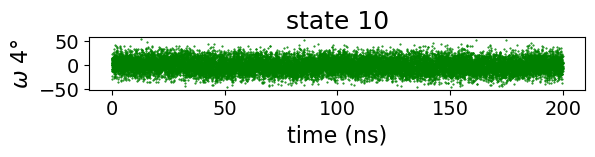

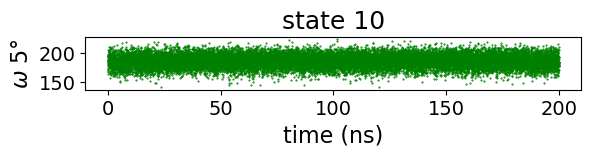

In [10]:
omega_all = (omega_all + 90.0) % 360.0 - 90.0

start = 0
nsnaps = omega_all.shape[1]
nreps = omega_all.shape[0]
residues_to_plot = [0, 1, 2, 3, 4, 5] #5
print()
num_residues = len(residues_to_plot)

ShowPlots = True

# Set default font sizes globally
plt.rc('font', size=16)         # controls default text sizes
plt.rc('axes', titlesize=18)    # fontsize of the axes title
plt.rc('axes', labelsize=16)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=14)   # fontsize of the tick labels
plt.rc('ytick', labelsize=14)   # fontsize of the tick labels
plt.rc('legend', fontsize=18)   # legend fontsize

# Plot omega angles vs time for selected residues for each replica
for i in [0, 10]:
    plt.figure(figsize=(5, 5))
    for panel, residue in enumerate(residues_to_plot, 1):
        plt.subplot(num_residues, 1, panel)
        t = np.arange(start, nsnaps) * 0.010  # Time axis in ns
        plt.plot(t, omega_all[i, start:nsnaps, residue], '.', ms=1, color='green')
        plt.xlabel('time (ns)')
        plt.ylabel(f'$\\omega$ {residue}°')
        plt.title(f'state {i}')
        #plt.tight_layout()
        plt.show()
    #plt.show()

In [11]:
data_path = 'traj_data/omegas_state0.pkl'

# Load the data
loaded_data = Data.load(data_path)
# Access the list of arrays
array_list = loaded_data.array_list

# Print a slice of the data
print(array_list[200:210])
# Print the shape
print(np.array(array_list).shape)

[[ 179.91881    -177.63403     -13.165404     28.74407     162.92235
    11.457667  ]
 [-179.05507     170.4438        5.232391     27.25025     154.34862
    10.3788    ]
 [-179.14403     160.93045      -0.5940052    16.546776    169.52235
     1.6571734 ]
 [ 171.2599      175.95268      10.159538     15.979595    156.96951
     6.5049257 ]
 [-173.64702     174.39423      14.880599      4.139963    166.51657
    10.294611  ]
 [ 175.5522      172.03311      -0.56534845   18.219513    161.04056
    33.639156  ]
 [ 171.40407     165.4057       12.171593     14.099887    169.5724
     8.56803   ]
 [-176.37363     178.0282       -6.0970297    22.746357    158.04439
   -13.639685  ]
 [ 174.1621     -169.85892       2.5797408     5.1501737   164.77448
     2.5772614 ]
 [ 179.52756     172.73909      19.086418      3.307409    160.8563
    -5.615189  ]]
(20001, 6)


In [12]:
nstates = 6

for i in range(nstates):
    omega_path = f"traj_data/omegas_state{i}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    print(f'state {i}:, {np.array(omegas).shape}')

state 0:, (20001, 6)
state 1:, (20001, 6)
state 2:, (20001, 6)
state 3:, (20001, 6)
state 4:, (20001, 6)
state 5:, (20001, 6)


### Extract the exchanged stated

In [13]:
current_state = np.arange(0, 8, 1).tolist()
current_state

[0, 1, 2, 3, 4, 5, 6, 7]

In [14]:
HREX_dir = '..'
HREX_list = [f"HREX_{i}" for i in range(1, 2)]

current_state = np.arange(0, 8, 1).tolist()

pattern = 'Repl ex'
output_file = 'replica_indices.dat'

states = []
states.append( current_state.copy() ) # Make a copy of initial_state

# DEbug:  Let's see if xtc is written BEFORE swap 
states.append( current_state.copy() ) # Make a copy of initial_state

VERBOSE = False

for HREX in HREX_list:
    HREX_path = f"{HREX_dir}/{HREX}"
    try:
        logfile = os.path.join(HREX_path , 'state_0/HREMD.part0001.log')
        with open(logfile, 'r') as file:
            lines = file.readlines()

            for line in lines:
                if pattern in line:
                    parts = line.strip().split()
                    if VERBOSE:
                        print(f'parts: {parts}')
                    for i in range(2, len(parts)):
                        if 'x' in parts[i]:
                            index1 = int(parts[i-1])
                            index2 = int(parts[i+1])
                            if VERBOSE:
                                print(current_state)
                                print('index1, index2', index1, index2)
                            # Swap the positions in the current state
                            tmp1, tmp2 = current_state[index1], current_state[index2]
                            if VERBOSE:
                                print('tmp1, tmp2', tmp1, tmp2)
                            current_state[index2] = tmp1
                            current_state[index1] = tmp2
                            if VERBOSE:
                                print(current_state)
                    states.append(current_state.copy())  # Append a copy of the last state
        
        # Append twice for the last frame
        states.append(current_state.copy())
        states.append(current_state.copy())

    except FileNotFoundError:
        print(f"The file {logfile} does not exist.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Remove the final two lines from states
if len(states) > 2:
    states = states[:-2]


# Write states to output_file
with open(output_file, 'w') as outfile:
    for state in states:
        outfile.write(' '.join(map(str, state)) + '\n')

print(f"Output saved to {output_file}")


Output saved to replica_indices.dat


In [15]:
all_omegas = [] # Load in the omega values for all replicas

state_num = 8

for state in range(state_num):  # Adjust the range to include all replicas
    omega_path = f"traj_data/omegas_state{state}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    all_omegas.append(np.array(omegas))
all_omegas = np.array(all_omegas)  # (nreps, nsnaps, nresidues)
print('all_omegas.shape', all_omegas.shape)
#print(all_omegas[:5])

# Arrange each snapshot by replica (not temp)
replica_indices = np.loadtxt('replica_indices.dat')
print("replica_indices.shape", replica_indices.shape)
#print(replica_indices)

all_omegas_by_replica = np.zeros(all_omegas.shape)

start = 0
nsnaps = 20001
nreps = 8
for i in range(nsnaps):
    Ind = np.argsort(replica_indices[i, :])
    all_omegas_by_replica[:, i, :] = all_omegas[Ind, i, :]

# Save the data for each state once
for rep in range(nreps):
    save_path = f"traj_data/omegas_rep{rep}.pkl"
    rep_object = Data(all_omegas_by_replica[rep, :, :])
    rep_object.save(save_path)
    print(f"Saved omegas for replica {rep} to {save_path}")
    #print(np.load(f'omega_data/omegas_rep{rep}.npy')[:5])

all_omegas.shape (8, 20001, 6)
replica_indices.shape (20001, 8)
Saved omegas for replica 0 to traj_data/omegas_rep0.pkl
Saved omegas for replica 1 to traj_data/omegas_rep1.pkl
Saved omegas for replica 2 to traj_data/omegas_rep2.pkl
Saved omegas for replica 3 to traj_data/omegas_rep3.pkl
Saved omegas for replica 4 to traj_data/omegas_rep4.pkl
Saved omegas for replica 5 to traj_data/omegas_rep5.pkl
Saved omegas for replica 6 to traj_data/omegas_rep6.pkl
Saved omegas for replica 7 to traj_data/omegas_rep7.pkl


In [16]:
# Adjust omega values into the range (-90, 270)
all_omegas_by_replica = (all_omegas_by_replica + 90.0) % 360.0 - 90.0

start = 0
nsnaps = 20001
nreps = 8
residues_to_plot = np.arange(0, 6).tolist()
num_residues = len(residues_to_plot)

ShowPlots = False

# Set default font sizes globally
plt.rc('font', size=16)         # controls default text sizes
plt.rc('axes', titlesize=18)    # fontsize of the axes title
plt.rc('axes', labelsize=16)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=14)   # fontsize of the tick labels
plt.rc('ytick', labelsize=14)   # fontsize of the tick labels
plt.rc('legend', fontsize=18)   # legend fontsize

# Plot omega angles vs time for selected residues for each replica
for i in range(nreps):
    plt.figure(figsize=(10, 9))
    for panel, residue in enumerate(residues_to_plot, 1):
        plt.subplot(num_residues, 1, panel)
        t = np.arange(start, nsnaps) * 0.010  # Time axis in ns
        plt.plot(t, all_omegas_by_replica[i, start:nsnaps, residue], '.', ms=1, color='green')
        plt.xlabel('time (ns)')
        plt.ylabel(f'$\\omega$ {residue}°')
        plt.title(f'Omega angles vs Time for replica {i} in 19AE1-4-A')
        
    plt.tight_layout()
    if ShowPlots:
        plt.show()
    else:
        outfilename = f'traj_data/Omega_angles_vs_Time_Replica_{i}_in_19AE1-4-A.png'
        plt.savefig(outfilename, format='png', transparent=True, dpi=600)
        print(f"Saved at: {outfilename}")
        plt.clf()  # Clear the figure for the next set of plots

Saved at: traj_data/Omega_angles_vs_Time_Replica_0_in_19AE1-4-A.png
Saved at: traj_data/Omega_angles_vs_Time_Replica_1_in_19AE1-4-A.png
Saved at: traj_data/Omega_angles_vs_Time_Replica_2_in_19AE1-4-A.png
Saved at: traj_data/Omega_angles_vs_Time_Replica_3_in_19AE1-4-A.png
Saved at: traj_data/Omega_angles_vs_Time_Replica_4_in_19AE1-4-A.png
Saved at: traj_data/Omega_angles_vs_Time_Replica_5_in_19AE1-4-A.png
Saved at: traj_data/Omega_angles_vs_Time_Replica_6_in_19AE1-4-A.png
Saved at: traj_data/Omega_angles_vs_Time_Replica_7_in_19AE1-4-A.png


<Figure size 1000x900 with 0 Axes>

<Figure size 1000x900 with 0 Axes>

<Figure size 1000x900 with 0 Axes>

<Figure size 1000x900 with 0 Axes>

<Figure size 1000x900 with 0 Axes>

<Figure size 1000x900 with 0 Axes>

<Figure size 1000x900 with 0 Axes>

<Figure size 1000x900 with 0 Axes>

## Plot Omega Desity Plot

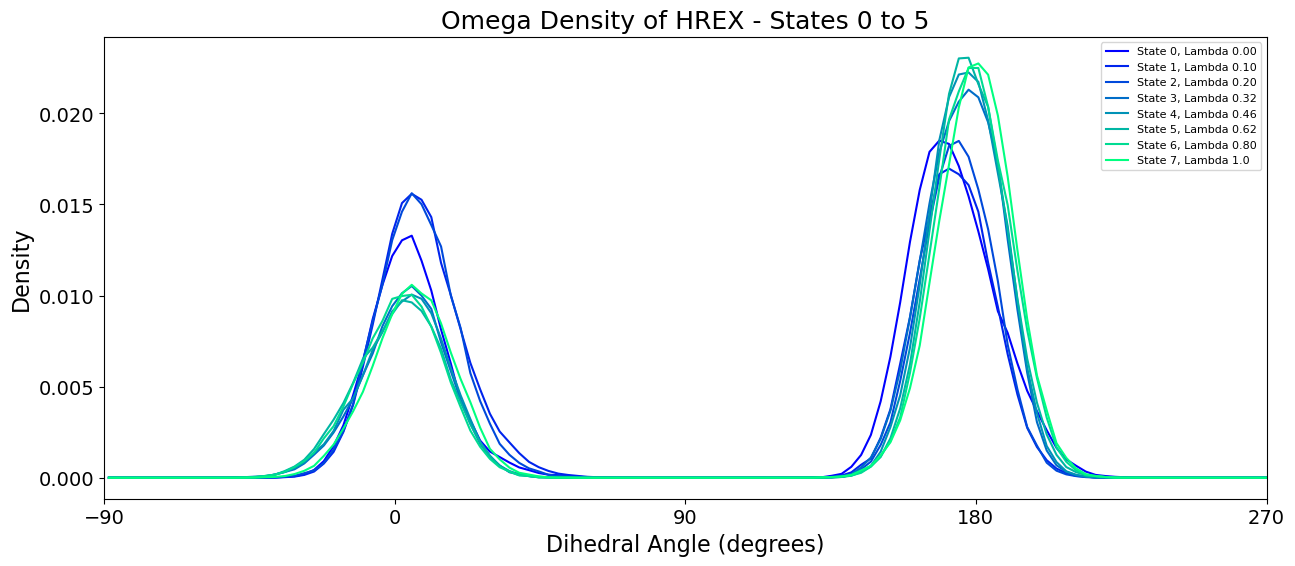

In [18]:
save_dir = 'traj_data'
num_states = 8
lambda_val = ['0.00',  '0.10',  '0.20',  '0.32',  '0.46',  '0.62',  '0.80',  '1.0' ]

fig, ax = plt.subplots(figsize=(15, 6))
cmap = cm.get_cmap('winter', num_states)
colors = [cmap(i) for i in range(num_states)]

for state in range(num_states):
    omega = Data.load(f"{save_dir}/omegas_state{state}.pkl").array_list  # Load each state
    combined_omega = np.vstack(omega)
    combined_omega = (combined_omega + 90.0) % 360.0 - 90.0

    bins = np.linspace(-90, 270, 120)
    counts, bin_edges = np.histogram(combined_omega, bins=bins, density=True)
    counts = np.concatenate([counts, counts[:1]])
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_centers = np.append(bin_centers, bin_centers[0] + 360)

    ax.plot(bin_centers, counts, color=colors[state], label=f'State {state}, Lambda {lambda_val[state]}')

ax.set_title('Omega Density of HREX - States 0 to 5')
ax.set_xlabel('Dihedral Angle (degrees)')
ax.set_ylabel('Density')
ax.set_xlim([-90, 270])
ax.set_xticks([-90, 0, 90, 180, 270])
ax.legend(loc='best', fontsize=8)

plt.show()


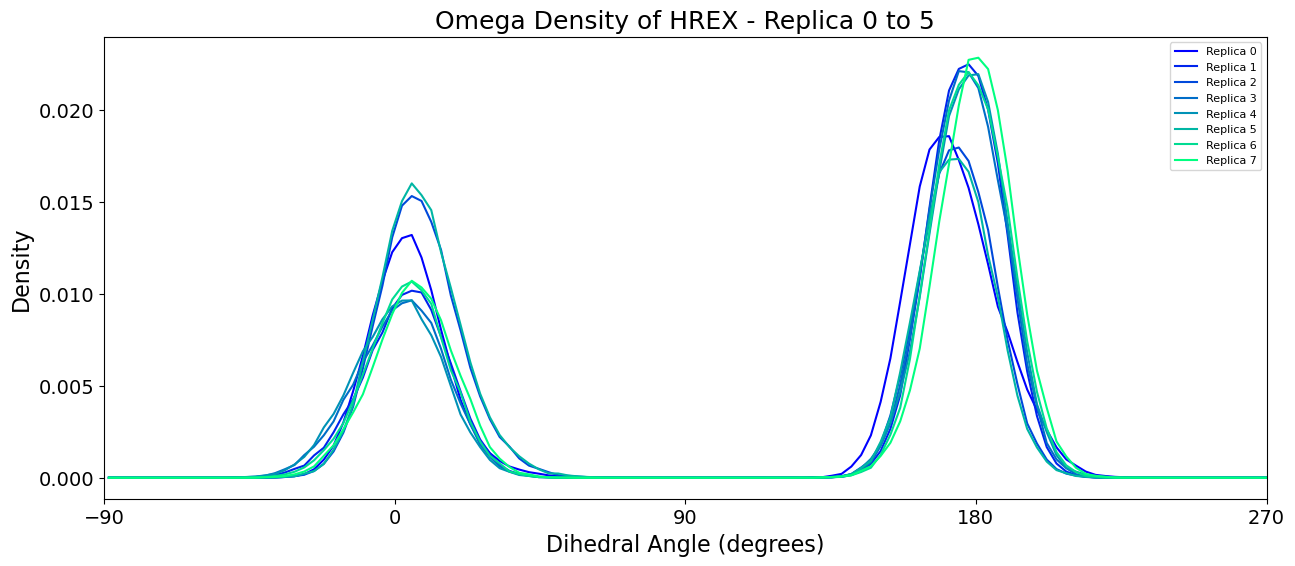

In [19]:
save_dir = 'traj_data'
num_rep = 8

fig, ax = plt.subplots(figsize=(15, 6))
cmap = cm.get_cmap('winter', num_rep)
colors = [cmap(i) for i in range(num_rep)]

for rep in range(num_rep):
    omega = Data.load(f"{save_dir}/omegas_rep{rep}.pkl").array_list  # Load each state
    combined_omega = np.vstack(omega)
    combined_omega = (combined_omega + 90.0) % 360.0 - 90.0

    bins = np.linspace(-90, 270, 120)
    counts, bin_edges = np.histogram(combined_omega, bins=bins, density=True)
    counts = np.concatenate([counts, counts[:1]])
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_centers = np.append(bin_centers, bin_centers[0] + 360)

    ax.plot(bin_centers, counts, color=colors[rep], label=f'Replica {rep}')

ax.set_title('Omega Density of HREX - Replica 0 to 5')
ax.set_xlabel('Dihedral Angle (degrees)')
ax.set_ylabel('Density')
ax.set_xlim([-90, 270])
ax.set_xticks([-90, 0, 90, 180, 270])
ax.legend(loc='best', fontsize=8)

plt.show()
